In [35]:
import pandas as pd 
import numpy as np

In [20]:
df=pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [21]:
df["income_cat"]=pd.cut(df["median_income"],bins=[0,1.5,2.5,3.5,4.5,5.5,6,np.inf],labels=[1,2,3,4,5,6,7])

In [22]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,7
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,7
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,7
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,6
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4


In [23]:
from sklearn.model_selection import StratifiedShuffleSplit # can do multiple splits

In [24]:
sss=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_idx,test_idx in sss.split(df,df["income_cat"]):
    train_set=df.iloc[train_idx]
    test_set=df.iloc[test_idx]

In [25]:
#droping "income_cat" column now

In [26]:
df=train_set.copy()

In [27]:
df.drop("income_cat",axis=1,inplace=True)

In [36]:
#Main data column is : meadian_house_value

Text(0.5, 1.0, 'Housing cost distribution of California')

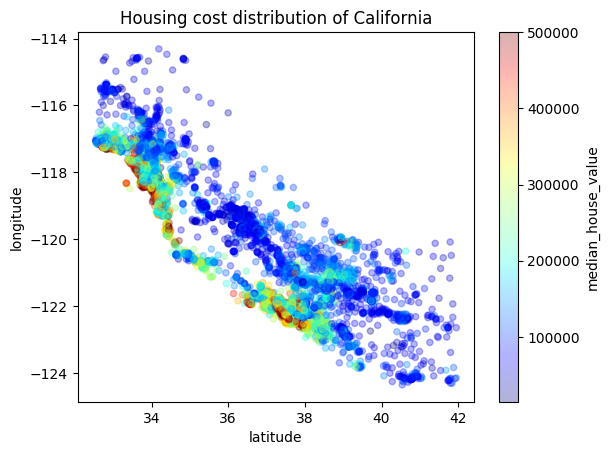

In [37]:
import matplotlib.pyplot as plt
df.plot(kind="scatter",x="latitude",y="longitude",cmap="jet",c="median_house_value",alpha=0.3)
plt.title("Housing cost distribution of California")


In [40]:
corr_matrix=df.select_dtypes(include="number").corr()

In [41]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924445,-0.104804,0.048569,0.075549,0.104147,0.061633,-0.020640,-0.048019
latitude,-0.924445,1.000000,0.007564,-0.041655,-0.074447,-0.113568,-0.078693,-0.074531,-0.142330
housing_median_age,-0.104804,0.007564,1.000000,-0.358649,-0.320703,-0.295197,-0.303502,-0.112855,0.107988
total_rooms,0.048569,-0.041655,-0.358649,1.000000,0.931112,0.858670,0.919694,0.194498,0.134691
total_bedrooms,0.075549,-0.074447,-0.320703,0.931112,1.000000,0.876602,0.980001,-0.008209,0.051318
population,0.104147,-0.113568,-0.295197,0.858670,0.876602,1.000000,0.905767,0.004350,-0.022912
households,0.061633,-0.078693,-0.303502,0.919694,0.980001,0.905767,1.000000,0.012383,0.067886
median_income,-0.020640,-0.074531,-0.112855,0.194498,-0.008209,0.004350,0.012383,1.000000,0.687715
median_house_value,-0.048019,-0.142330,0.107988,0.134691,0.051318,-0.022912,0.067886,0.687715,1.000000


In [45]:
corr_matrix["total_rooms"].sort_values(ascending=False)

total_rooms           1.000000
total_bedrooms        0.931112
households            0.919694
population            0.858670
median_income         0.194498
median_house_value    0.134691
longitude             0.048569
latitude             -0.041655
housing_median_age   -0.358649
Name: total_rooms, dtype: float64

In [48]:
# SCATTER MATRIX:
from pandas.plotting import scatter_matrix

array([[<Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='total_bedrooms', ylabel='median_income'>],
       [<Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='total_bedrooms', ylabel='median_house_value'>],
       [<Axes: xlabel='median_income', ylabel='total_bedrooms'>,
        <Axes: xlabel='median_house_value', ylabel='total_bedrooms'>,
        <Axes: xlabel='total_bedrooms', ylabel='total_bedrooms'>]],
      dtype=object)

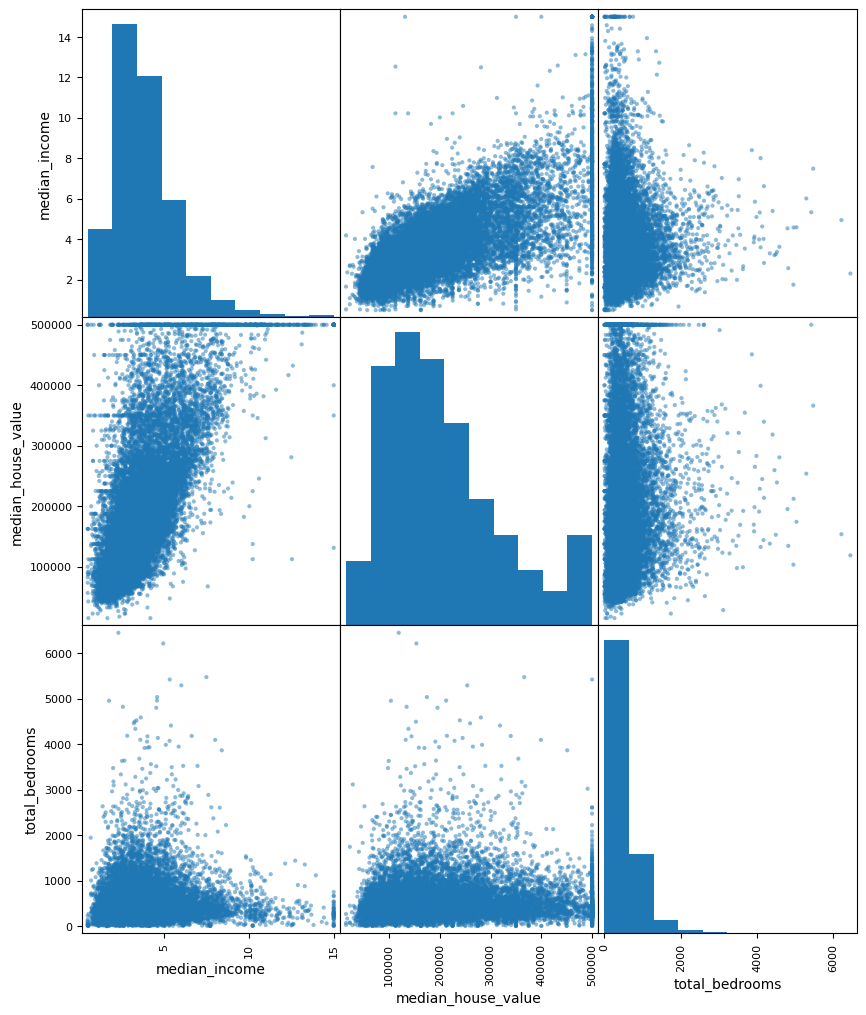

In [49]:
attributes=["median_income","median_house_value","total_bedrooms"]
scatter_matrix(df[attributes],figsize=(10,12))